In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
import joblib

In [3]:
# data gathering
data = pd.read_csv("../data/student_performance_data.csv")
data.head()

,study_hours,attendance_rate,prev_exam_score,grade
0,3.7,0.85,86,B
1,9.5,0.77,51,B
2,7.3,0.65,55,C
3,6.0,0.91,63,A
4,1.6,0.84,58,C


In [7]:
# data preprocessing
data.sample(5)

,study_hours,attendance_rate,prev_exam_score,grade
494,4.6,0.68,92,B
335,0.4,0.71,84,C
499,9.9,0.72,52,A
184,2.6,0.96,88,B
238,6.5,0.72,50,C


In [8]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   study_hours      500 non-null    float64
 1   attendance_rate  500 non-null    float64
 2   prev_exam_score  500 non-null    int64  
 3   grade            500 non-null    str    
dtypes: float64(2), int64(1), str(1)
memory usage: 15.8 KB


In [12]:
# check null and duplicate values
print("Null values:\n", data.isnull().sum())
print("Duplicate values:\n", data.duplicated().sum())



Null values:
 study_hours        0
attendance_rate    0
prev_exam_score    0
grade              0
dtype: int64
Duplicate values:
 0


In [ ]:
data.drop_duplicates(inplace = True)
data.dropna(inplace = True)

In [13]:
data.columns

Index(['study_hours', 'attendance_rate', 'prev_exam_score', 'grade'], dtype='str')

In [14]:
data["study_hours"].dtype

dtype('float64')

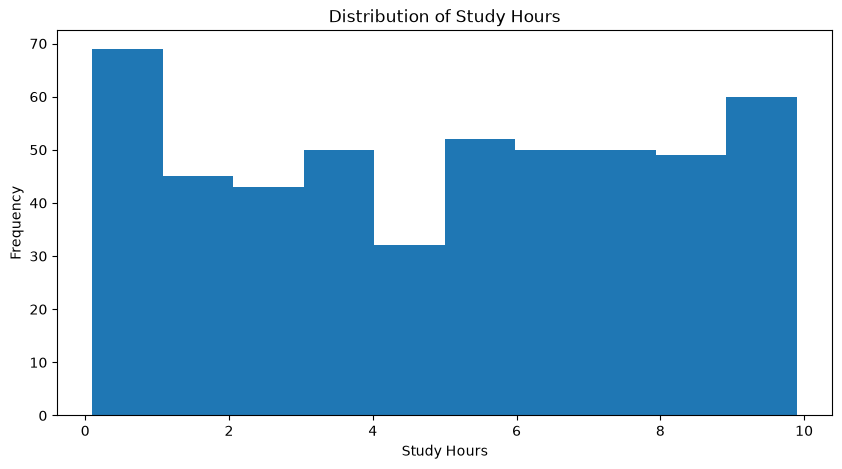

In [20]:
plt.figure(figsize = (10, 5))
plt.hist(data["study_hours"], bins = 10)
plt.title("Distribution of Study Hours")
plt.xlabel("Study Hours")
plt.ylabel("Frequency")
plt.show()


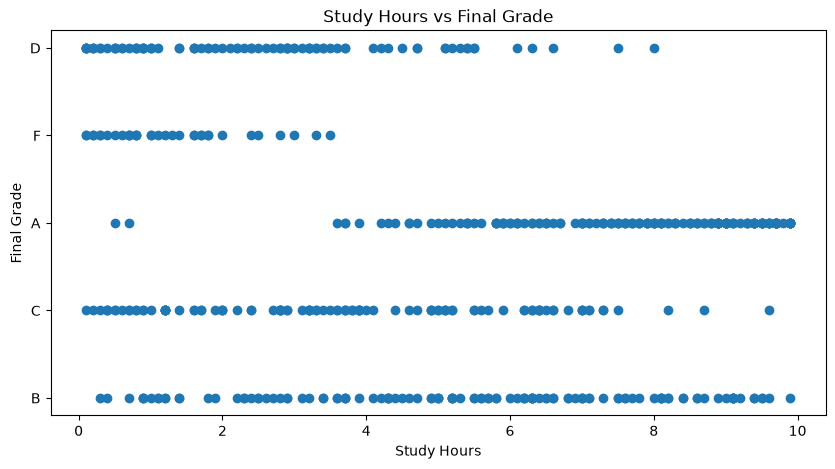

In [21]:
# bi variate analysis
plt.figure(figsize = (10, 5))
plt.scatter(x = "study_hours", y = "grade", data = data)
plt.title("Study Hours vs Final Grade")
plt.xlabel("Study Hours")
plt.ylabel("Final Grade")
plt.show()

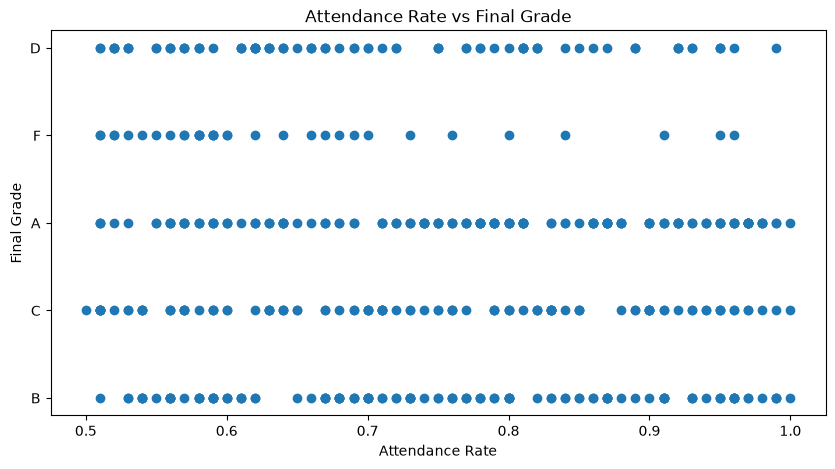

In [23]:
plt.figure(figsize = (10, 5))
plt.scatter(x = "attendance_rate", y = "grade", data = data)
plt.title("Attendance Rate vs Final Grade")
plt.xlabel("Attendance Rate")
plt.ylabel("Final Grade")
plt.show()

In [ ]:

# multivariate analysis
plt.figure(figsize = (10, 5))
plt.boxplot(x = "study_hours", y = "grade", data = data)
plt.title("Study Hours vs Final Grade")
plt.show()

In [30]:
X = data.iloc[:, [0, 1, 2]]
y = data.iloc[:, 3]

In [34]:
DTC = DecisionTreeClassifier()
DTC.fit(X, y)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [35]:
DTC.predict(X)

array(['B', 'B', 'C', 'A', 'C', 'F', 'C', 'A', 'B', 'A', 'D', 'A', 'A',
       'D', 'F', 'F', 'F', 'C', 'B', 'D', 'A', 'D', 'B', 'A', 'A', 'A',
       'C', 'D', 'C', 'D', 'B', 'C', 'B', 'A', 'A', 'A', 'D', 'D', 'B',
       'B', 'C', 'C', 'B', 'A', 'D', 'B', 'B', 'B', 'B', 'D', 'A', 'A',
       'A', 'A', 'A', 'B', 'C', 'D', 'C', 'D', 'C', 'D', 'A', 'C', 'C',
       'A', 'C', 'A', 'F', 'A', 'A', 'C', 'D', 'A', 'B', 'A', 'B', 'F',
       'B', 'C', 'B', 'A', 'C', 'D', 'D', 'F', 'B', 'C', 'A', 'B', 'C',
       'C', 'A', 'B', 'A', 'C', 'B', 'B', 'C', 'F', 'F', 'C', 'C', 'C',
       'B', 'B', 'B', 'A', 'B', 'D', 'C', 'C', 'A', 'B', 'A', 'B', 'A',
       'D', 'A', 'A', 'B', 'A', 'C', 'B', 'D', 'D', 'B', 'A', 'D', 'D',
       'A', 'C', 'C', 'D', 'A', 'D', 'D', 'A', 'D', 'A', 'C', 'B', 'B',
       'D', 'F', 'D', 'A', 'A', 'D', 'D', 'B', 'B', 'B', 'A', 'A', 'C',
       'A', 'B', 'D', 'A', 'B', 'B', 'B', 'D', 'D', 'B', 'D', 'C', 'F',
       'A', 'C', 'D', 'C', 'B', 'A', 'C', 'A', 'C', 'A', 'B', 'B

In [37]:
DTC.score(X, y)

0.998

In [ ]:
joblib.dump(DTC, "../model/decision_tree.pkl")

['decision_tree.pkl']